# Detecção de Fraude em Transações de Cartão de Crédito
### Projeto Final — Introdução ao Aprendizado de Máquina (IML 2026)

---

## Introdução

A fraude em cartões de crédito representa um problema de alto impacto financeiro e social. Instituições bancárias processam milhões de transações diariamente e precisam identificar, em tempo real, quais operações são potencialmente fraudulentas — sem bloquear indevidamente transações legítimas.

Este projeto aplica técnicas de **Aprendizado de Máquina Supervisionado** para classificar transações como legítimas ou fraudulentas, com foco em dois métodos clássicos de análise discriminante: **LDA** (Linear Discriminant Analysis) e **QDA** (Quadratic Discriminant Analysis).

## Objetivo

Desenvolver e avaliar modelos de classificação capazes de detectar fraudes em transações de cartão de crédito, abordando o desafio do **desbalanceamento de classes** com uma estratégia de geração de dados sintéticos baseada em distribuições estatísticas.

## Dataset

O dataset utilizado é o **Credit Card Fraud** disponível publicamente no Kaggle (`dhanushnarayananr/credit-card-fraud`), contendo **1.000.000 transações** com 7 atributos preditores e 1 variável alvo.

### Descrição das Features

| Feature | Tipo | Descrição |
|---------|------|-----------|
| `distance_from_home` | Contínua | Distância entre o local da transação e a residência do cliente (km) |
| `distance_from_last_transaction` | Contínua | Distância entre a transação atual e a anterior (km) |
| `ratio_to_median_purchase_price` | Contínua | Razão entre o valor da compra e o preço mediano histórico do cliente |
| `repeat_retailer` | Binária | 1 se o cliente já comprou neste estabelecimento antes |
| `used_chip` | Binária | 1 se a transação usou o chip físico do cartão |
| `used_pin_number` | Binária | 1 se a senha PIN foi utilizada |
| `online_order` | Binária | 1 se a transação foi realizada online |

**Variável alvo:**
- `fraud`: Binária — 0 para transação legítima, 1 para transação fraudulenta

---
## 1. Importações e Configurações

Importamos as bibliotecas necessárias para manipulação de dados e definimos as constantes globais que organizam as features por tipo. Manter a ordem das colunas como constante evita erros de indexação ao longo do pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# MANTER ORDEM DAS COLUNAS PARA EVITAR ERROS DE INDEXAÇÃO
COLUNAS_CONTINUAS = [
    "distance_from_home",
    "distance_from_last_transaction",
    "ratio_to_median_purchase_price"
]

COLUNAS_BINARIAS = [
    "repeat_retailer",
    "used_chip",
    "used_pin_number",
    "online_order"
]

---
## 2. Análise Exploratória de Dados (EDA)

In [3]:
df = pd.read_csv("dataset/card_transdata.csv")

In [4]:
# Informações gerais sobre os tipos de dados e valores nulos
print("--- Informações Gerais do Dataset ---")
df.info()

print("\n--- Estatísticas Descritivas ---")
display(df.describe())

--- Informações Gerais do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB

--- Estatísticas Descritivas ---


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


### 2.1 Análise de Desbalanceamento da Classe Alvo

Uma característica crítica deste dataset é o desbalanceamento de classes. Vamos plotar a proporção de transações legítimas (0) versus fraudulentas (1) para visualizar a escala desse desbalanceamento.

Transações Legítimas (0): 912597 (91.26%)
Transações Fraudulentas (1): 87403 (8.74%)


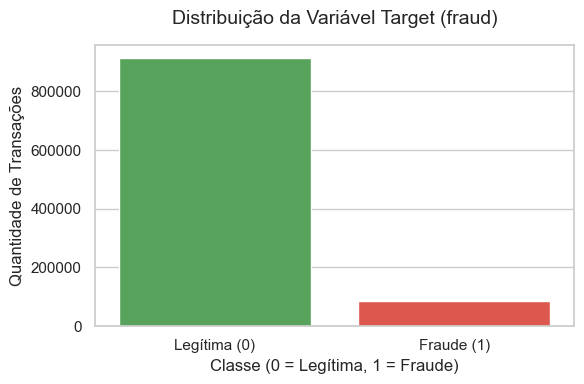

In [5]:
# Configurações globais de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

# Contagem e percentual
contagem_classes = df['fraud'].value_counts()
percentual_classes = df['fraud'].value_counts(normalize=True) * 100

print(f"Transações Legítimas (0): {contagem_classes[0]} ({percentual_classes[0]:.2f}%)")
print(f"Transações Fraudulentas (1): {contagem_classes[1]} ({percentual_classes[1]:.2f}%)")

# Gráfico de distribuição do target
plt.figure(figsize=(6, 4))
sns.barplot(x=contagem_classes.index, y=contagem_classes.values, hue=contagem_classes.index, palette=['#4CAF50', '#F44336'], legend=False)
plt.title('Distribuição da Variável Target (fraud)', fontsize=14, pad=15)
plt.xlabel('Classe (0 = Legítima, 1 = Fraude)', fontsize=12)
plt.ylabel('Quantidade de Transações', fontsize=12)
plt.xticks([0, 1], ['Legítima (0)', 'Fraude (1)'])
plt.tight_layout()
plt.show()

### 2.2 Distribuição das Variáveis Contínuas por Classe

Para entender o comportamento das features contínuas, comparamos as suas distribuições agrupadas por classe. Como essas variáveis apresentam valores discrepantes extremos (outliers), utilizaremos boxplots com escala logarítmica no eixo Y para facilitar a comparação visual das medianas e quartis.

In [ ]:
# Médias das variáveis contínuas por classe
print("Médias das variáveis contínuas agrupadas por classe:")
display(df.groupby('fraud')[COLUNAS_CONTINUAS].mean())

# Boxplots comparativos das features contínuas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(COLUNAS_CONTINUAS):
    sns.boxplot(ax=axes[i], x='fraud', y=col, data=df, hue='fraud', palette=['#4CAF50', '#F44336'], legend=False)
    axes[i].set_title(f'Distribuição de {col}', fontsize=12)
    axes[i].set_xlabel('Classe (0 = Legítima, 1 = Fraude)')
    axes[i].set_yscale('log')  # Escala logarítmica para lidar com outliers
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Legítima', 'Fraude'])
    
plt.suptitle('Comparação de Features Contínuas por Classe (Escala Logarítmica)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Médias das variáveis contínuas agrupadas por classe:


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
fraud,,,
0.0,22.832976,4.301391,1.423642
1.0,66.261876,12.712185,6.006323


### 2.3 Proporção de Variáveis Binárias por Classe

Para as variáveis binárias, calculamos a proporção de ocorrência (média da feature, que equivale à taxa de transações com valor 1) para cada classe.

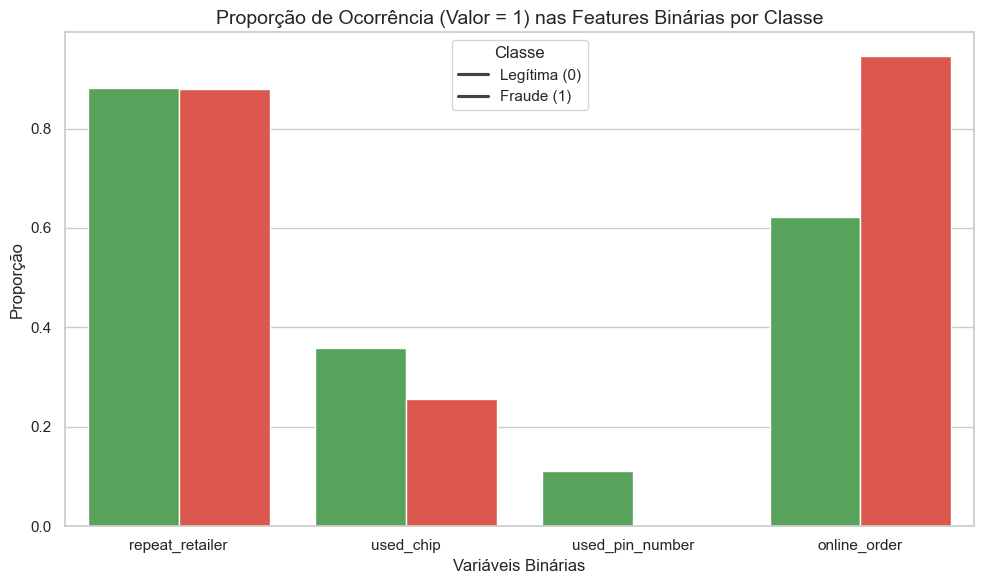

In [ ]:
lista_props = []
for col in COLUNAS_BINARIAS:
    prop = df.groupby('fraud')[col].mean().reset_index()
    prop['feature'] = col
    prop.columns = ['fraud', 'proporcao', 'feature']
    lista_props.append(prop)
    
df_bin_props = pd.concat(lista_props, ignore_index=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='feature', y='proporcao', hue='fraud', data=df_bin_props, palette=['#4CAF50', '#F44336'])
plt.title('Proporção de Ocorrência (Valor = 1) nas Features Binárias por Classe', fontsize=14)
plt.xlabel('Variáveis Binárias')
plt.ylabel('Proporção')
plt.legend(title='Classe', labels=['Legítima (0)', 'Fraude (1)'])
plt.tight_layout()
plt.show()

### 2.4 Matriz de Correlação

A matriz de correlação linear ajuda a identificar quais features possuem maior associação linear direta com a ocorrência de fraudes e se há redundância (multicolinearidade) entre as variáveis preditoras.

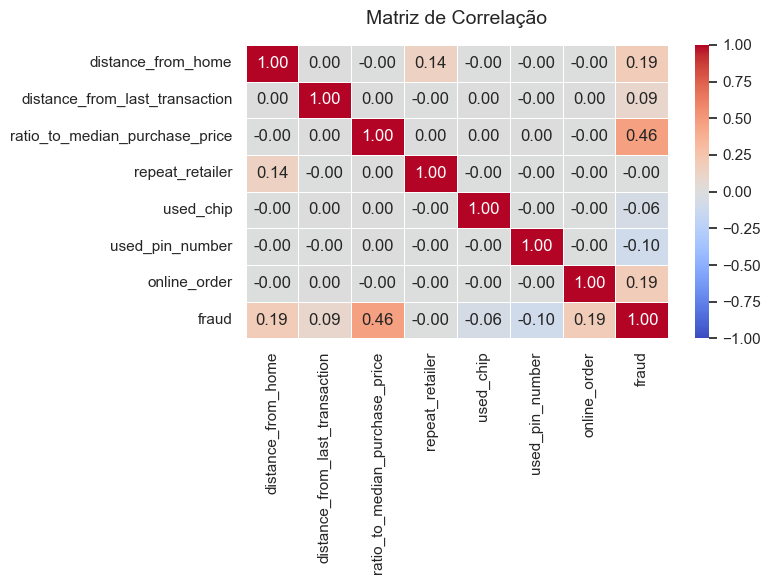

In [ ]:
# Calcular a matriz de correlação
matriz_corr = df.corr()

# Heatmap da matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

---
## 3. Pré-processamento

In [ ]:
def gen_continuas(df_train_fraud, n_sintetico):
    """
    Gera dados sintéticos contínuos usando distribuição multivariada normal
    """
    X_cont = df_train_fraud[COLUNAS_CONTINUAS].values
    mu = X_cont.mean(axis=0)
    Sigma = np.cov(X_cont, rowvar=False)
    rng = np.random.default_rng(seed=4267)
    X_cont_sintetico = rng.multivariate_normal(mu, Sigma, size=n_sintetico)
    return X_cont_sintetico

def gen_binarias(df_train_fraud, n_sintetico):
    """
    Gera dados sintéticos binários usando Bernoulli

    """
    prob_binarias = {}
    rng = np.random.default_rng(seed=4267)

    for col in COLUNAS_BINARIAS:
        prob_binarias[col] = df_train_fraud[col].mean()
    
    binarias_sinteticas = {}
    for col in COLUNAS_BINARIAS:
        p = prob_binarias[col]
        binarias_sinteticas[col] = rng.binomial(1, p, size=n_sintetico)
    
    return binarias_sinteticas

### 3.2 Divisão Treino/Teste

O dataset é dividido em **80% treino** e **20% teste**. O parâmetro `stratify=y` garante que a proporção de fraudes seja preservada em ambos os conjuntos — fundamental em datasets desbalanceados. A semente `random_state=4267` assegura reprodutibilidade dos resultados.

In [ ]:
# Separar train e teste para depois gerar os dados sintéticos apenas no conjunto de treino
from sklearn.model_selection import train_test_split
# Drop da coluna target
X = df[COLUNAS_CONTINUAS + COLUNAS_BINARIAS].values
y = df["fraud"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4267, stratify=y)

### 3.3 Geração dos Dados Sintéticos e Balanceamento

A quantidade de amostras sintéticas é calculada como:

$$n_{\text{sintético}} = \left\lfloor \frac{|n_{\text{legítimas}} - n_{\text{fraudes}}|}{1.5} \right\rfloor$$

O divisor **1.5** é uma escolha deliberada: em vez de equalizar completamente as classes (50/50), reduzimos o desbalanceamento de forma moderada. Oversampling excessivo pode levar o modelo a aprender padrões artificiais dos dados sintéticos, prejudicando a generalização.

In [ ]:
df_train = pd.DataFrame(X_train, columns=COLUNAS_CONTINUAS + COLUNAS_BINARIAS)
# SELECIONA APENAS LINHAS COM FRAUD = 1
fraud_data = df_train[y_train == 1.0]   

# GERAR QUANTIDADE NECESSARIA PARA BALANCEAR O DATASET
n_sintetico = int(abs((y_train == 1.0).sum() - (y_train == 0.0).sum()) // 1.5)
# GERAR DADOS (FEATURES CONTINUAS) PARA A CLASSE MINORITÁRIA (FRAUDULENTAS)
X_cont_sintetico = gen_continuas(fraud_data, n_sintetico)

# GERAR DADOS (FEATURES BINÁRIAS) PARA A CLASSE MINORITÁRIA (FRAUDULENTAS)
X_bin_sintetico = gen_binarias(fraud_data, n_sintetico)
df_sintetico = pd.DataFrame(X_cont_sintetico, columns=COLUNAS_CONTINUAS)

for col in COLUNAS_BINARIAS:
    df_sintetico[col] = X_bin_sintetico[col]

df_sintetico["fraud"] = 1.0

O dataset de treino balanceado é formado pela **concatenação** do treino original com os dados sintéticos gerados. A distribuição resultante é exibida abaixo:

In [ ]:
df_train["fraud"] = y_train

df_balanceado_train = pd.concat(
    [df_train, df_sintetico],
    ignore_index=True
)

print(df_balanceado_train["fraud"].value_counts())

fraud
0.0    730078
1.0    510026
Name: count, dtype: int64


Transações Legítimas (0): 730078 (58.87%)
Transações Fraudulentas (1): 510026 (41.13%)


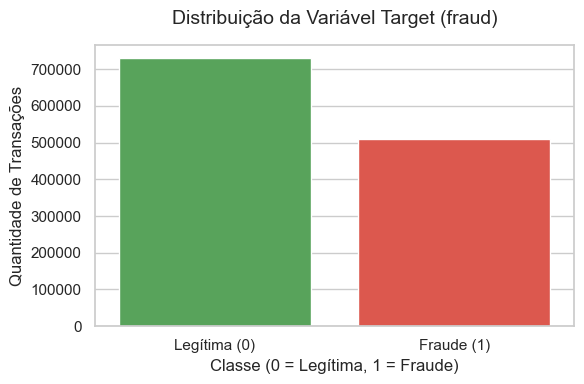

In [ ]:
# Configurações globais de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

# Contagem e percentual
contagem_classes = df_balanceado_train['fraud'].value_counts()
percentual_classes = df_balanceado_train['fraud'].value_counts(normalize=True) * 100

print(f"Transações Legítimas (0): {contagem_classes[0]} ({percentual_classes[0]:.2f}%)")
print(f"Transações Fraudulentas (1): {contagem_classes[1]} ({percentual_classes[1]:.2f}%)")

# Gráfico de distribuição do target
plt.figure(figsize=(6, 4))
sns.barplot(x=contagem_classes.index, y=contagem_classes.values, hue=contagem_classes.index, palette=['#4CAF50', '#F44336'], legend=False)
plt.title('Distribuição da Variável Target (fraud)', fontsize=14, pad=15)
plt.xlabel('Classe (0 = Legítima, 1 = Fraude)', fontsize=12)
plt.ylabel('Quantidade de Transações', fontsize=12)
plt.xticks([0, 1], ['Legítima (0)', 'Fraude (1)'])
plt.tight_layout()
plt.show()

### 3.4 Efeito dos dados sintéticos nas distribuições

Repetimos a análise da secção **2.2** sobre o conjunto de **treino balanceado**, para comparar com a EDA do dataset completo. Como as variáveis contínuas apresentam outliers extremos, utilizamos boxplots com **escala logarítmica** no eixo Y — a mesma convenção da secção 2.2 — para facilitar a comparação das medianas e dos quartis entre classes.

Médias das variáveis contínuas agrupadas por classe:


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
fraud,,,
0.0,22.830981,4.299649,1.424268
1.0,66.571690,12.729947,6.007745


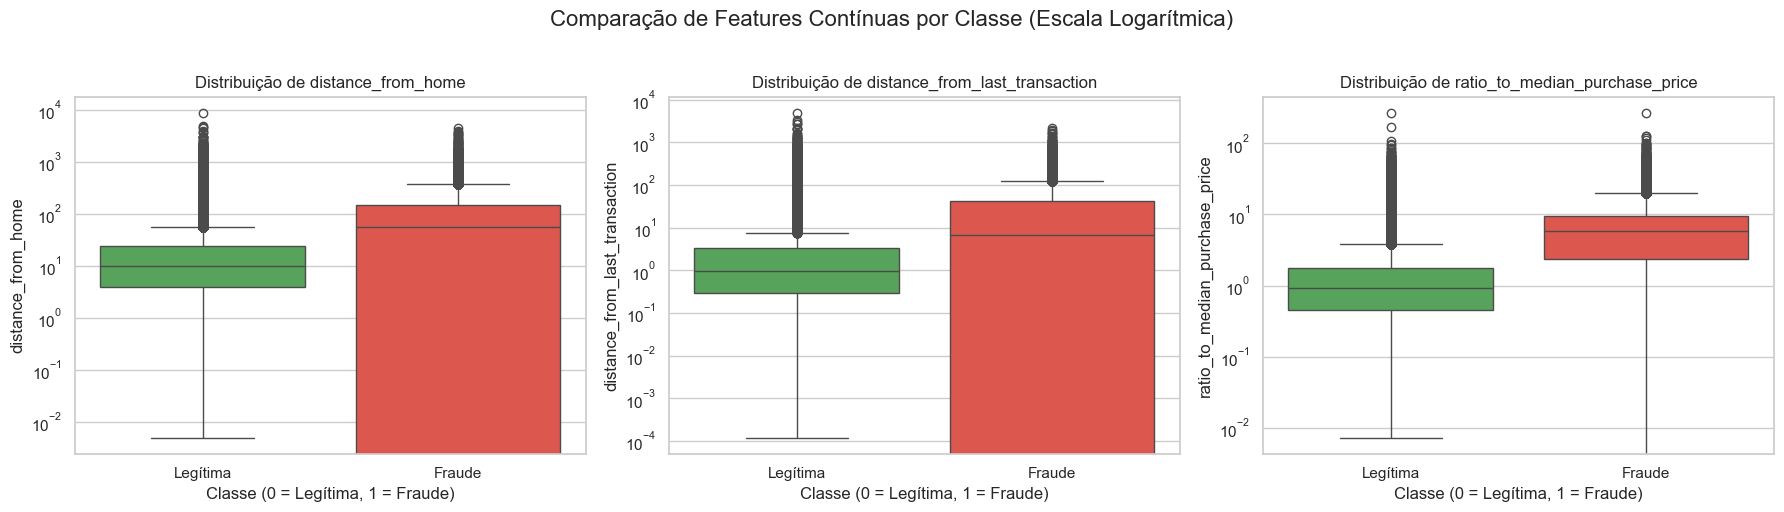

In [ ]:
# Médias das variáveis contínuas por classe
print("Médias das variáveis contínuas agrupadas por classe:")
display(df_balanceado_train.groupby('fraud')[COLUNAS_CONTINUAS].mean())

# Boxplots comparativos das features contínuas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(COLUNAS_CONTINUAS):
    sns.boxplot(ax=axes[i], x='fraud', y=col, data=df_balanceado_train, hue='fraud', palette=['#4CAF50', '#F44336'], legend=False)
    axes[i].set_title(f'Distribuição de {col}', fontsize=12)
    axes[i].set_xlabel('Classe (0 = Legítima, 1 = Fraude)')
    axes[i].set_yscale('log')  # Escala logarítmica para lidar com outliers
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Legítima', 'Fraude'])
    
plt.suptitle('Comparação de Features Contínuas por Classe (Escala Logarítmica)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

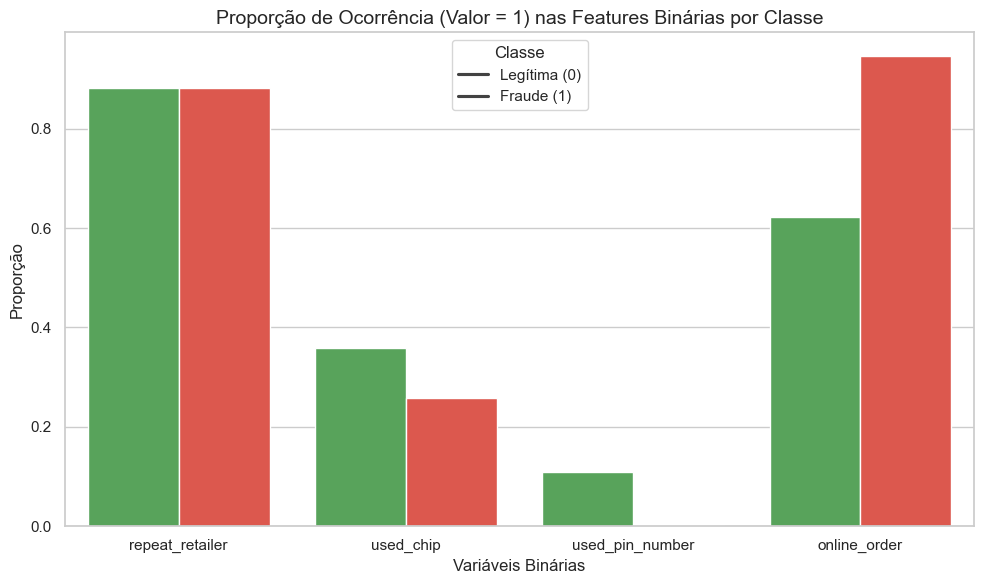

In [ ]:
lista_props = []
for col in COLUNAS_BINARIAS:
    prop = df_balanceado_train.groupby('fraud')[col].mean().reset_index()
    prop['feature'] = col
    prop.columns = ['fraud', 'proporcao', 'feature']
    lista_props.append(prop)
    
df_bin_props = pd.concat(lista_props, ignore_index=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='feature', y='proporcao', hue='fraud', data=df_bin_props, palette=['#4CAF50', '#F44336'])
plt.title('Proporção de Ocorrência (Valor = 1) nas Features Binárias por Classe', fontsize=14)
plt.xlabel('Variáveis Binárias')
plt.ylabel('Proporção')
plt.legend(title='Classe', labels=['Legítima (0)', 'Fraude (1)'])
plt.tight_layout()
plt.show()

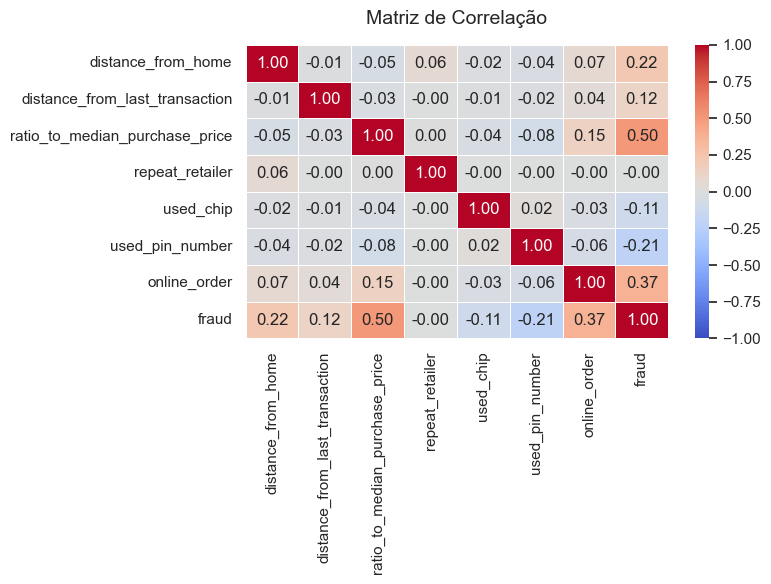

In [ ]:
# Calcular a matriz de correlação
matriz_corr = df_balanceado_train.corr()

# Heatmap da matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

**Síntese do balanceamento:**

- A proporção global de classes no treino passou de ~**91%/9%** para ~**59%/41%** — redução substancial do desbalanceamento, sem equalização completa (coerente com o divisor 1,5 na fórmula de oversampling).

- O oversampling **altera sobretudo a contagem** de exemplos fraudulentos; o perfil das transações **legítimas** nas features permanece estável.

- Nas **contínuas**, os sintéticos deslocam a forma da distribuição de fraude nos boxplots (mediana e quartis), embora as médias por classe se mantenham próximas das originais.

- Nas **binárias**, as taxas por classe mantêm-se essencialmente as mesmas, preservando os contrastes observados na EDA inicial.

In [ ]:
X_train_balanceado = df_balanceado_train.drop(columns=["fraud"]).values
y_train_balanceado = df_balanceado_train["fraud"].values

---
## 4. Modelagem

Treinamos dois classificadores da família de **Análise Discriminante**, ambos baseados na hipótese de que cada classe segue uma distribuição Gaussiana multivariada.

### 4.1 LDA — Linear Discriminant Analysis

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis        
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_balanceado, y_train_balanceado)
y_pred = lda.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1-Score: {f1}")


Accuracy: 0.958935
Precision: 0.7358269720101781
Recall: 0.8271265945884103
F1-Score: 0.7788101586275619


### 4.2 QDA — Quadratic Discriminant Analysis

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis        

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_balanceado, y_train_balanceado)
y_pred = qda.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1-Score: {f1}")


Accuracy: 0.942525
Precision: 0.6082224472085623
Recall: 0.9622447228419427
F1-Score: 0.7453308815384274


### 4.3 Regressão Logística

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=4267)
lr.fit(X_train_balanceado, y_train_balanceado)
y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
print(f"Accuracy: {acc_lr}")
print(f"Precision: {prec_lr}")
print(f"Recall: {rec_lr}")
print(f"F1-Score: {f1_lr}")

Accuracy: 0.94473
Precision: 0.6248688556440645
Recall: 0.9199130484526057
F1-Score: 0.7442151055164754


### 4.4 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=4267, n_jobs=-1)
rf.fit(X_train_balanceado, y_train_balanceado)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf}")
print(f"Precision: {prec_rf}")
print(f"Recall: {rec_rf}")
print(f"F1-Score: {f1_rf}")

Accuracy: 0.99767
Precision: 0.974034657602942
Recall: 1.0
F1-Score: 0.9868465620413233


---
## 5. Análise Comparativa dos Resultados

### 5.1 Curvas ROC e AUC

Para comparar o desempenho dos classificadores em diferentes limiares de decisão, plotamos as curvas ROC no conjunto de teste e calculamos a AUC de cada modelo.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades da classe positiva (fraude = 1)
y_score_lda = lda.predict_proba(X_test)[:, 1]
y_score_qda = qda.predict_proba(X_test)[:, 1]
y_score_lr = lr.predict_proba(X_test)[:, 1]
y_score_rf = rf.predict_proba(X_test)[:, 1]

# Cálculo das curvas ROC e AUC
fpr_lda, tpr_lda, _ = roc_curve(y_test, y_score_lda)
fpr_qda, tpr_qda, _ = roc_curve(y_test, y_score_qda)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)

auc_lda = roc_auc_score(y_test, y_score_lda)
auc_qda = roc_auc_score(y_test, y_score_qda)
auc_lr = roc_auc_score(y_test, y_score_lr)
auc_rf = roc_auc_score(y_test, y_score_rf)

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_lda, tpr_lda, label=f"LDA (AUC = {auc_lda:.4f})", linewidth=2)
plt.plot(fpr_qda, tpr_qda, label=f"QDA (AUC = {auc_qda:.4f})", linewidth=2)
plt.plot(fpr_lr, tpr_lr, label=f"Regressão Logística (AUC = {auc_lr:.4f})", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})", linewidth=2)

# Classificador aleatório
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline Aleatório')

plt.title("Curvas ROC - Comparação dos Classificadores")
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC LDA: {auc_lda:.4f}")
print(f"AUC QDA: {auc_qda:.4f}")
print(f"AUC Regressão Logística: {auc_lr:.4f}")
print(f"AUC Random Forest: {auc_rf:.4f}")